In [36]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from _src import EvidentialMLP, train_ern 

In [2]:
# 1D Dataset Generation with Outliers
def generate_1d_data(func, n=100, noise_std=0.2, outlier_ratio=0.03):
    # Generate x values uniformly distributed between 0 and 2π
    x = np.linspace(0, 2 * np.pi, n)
    
    # True function: sine wave
    y_true = func(x)
    
    # Add Gaussian noise to y values
    y = y_true + np.random.normal(0, noise_std, x.shape[0])
    
    # Insert outliers
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = max(y_true) + 5 + np.random.uniform(-0.1, 0.1, n_outliers)
    
    return x, y, y_true, outlier_indices


# Generate 1D dataset with outliers
x, y, y_true, outlier_indices = generate_1d_data(np.sin, n=100, noise_std=0.2, outlier_ratio=0.05)

# Convert the data to numpy arrays for Plotly
x = x
y = y
y_true = y_true
outliers_x = x[outlier_indices]
outliers_y = y[outlier_indices]

# Create traces for plotly
true_func_trace = go.Scatter(x=x, y=y_true, mode='lines', name='True function (sin(2x))', line=dict(color='red'))
data_trace = go.Scatter(x=x, y=y, mode='markers', name='Data with noise and outliers', marker=dict(color='blue', size=6))
outliers_trace = go.Scatter(x=outliers_x, y=outliers_y, mode='markers', name='Outliers', marker=dict(color='orange', size=8))

# Combine the traces
fig = go.Figure(data=[true_func_trace, data_trace, outliers_trace])

# Update layout for better visualization
fig.update_layout(
    title="1D Data with Noise and Outliers",
    xaxis_title="x",
    yaxis_title="y",
    showlegend=True,
    legend=dict(
        x=0,
        y=-0.2,
        orientation="h"
    )
)

# Show plot
fig.show()

In [3]:
true_func = lambda x: np.sin(2 * x) * x 


# Generate 1D dataset with outliers
x, y, y_true, outlier_indices = generate_1d_data(true_func, n=30, noise_std=1., outlier_ratio=0.05)

# Convert the data to numpy arrays for Plotly
x = x
y = y
y_true = y_true
outliers_x = x[outlier_indices]
outliers_y = y[outlier_indices]

# Create traces for plotly
true_func_trace = go.Scatter(x=x, y=y_true, mode='lines', name='True function', line=dict(color='red'))
data_trace = go.Scatter(x=x, y=y, mode='markers', name='Data with noise', marker=dict(color='blue', size=6))
outliers_trace = go.Scatter(x=outliers_x, y=outliers_y, mode='markers', name='Outliers', marker=dict(color='orange', size=8))

# Combine the traces
fig = go.Figure(data=[true_func_trace, data_trace, outliers_trace])

# Update layout for better visualization
fig.update_layout(
    title="1D Data with Noise and Outliers",
    xaxis_title="x",
    yaxis_title="y",
    showlegend=True,
    legend=dict(
        x=0,
        y=-0.2,
        orientation="h"
    )
)

# Show plot
fig.show()

In [37]:
import numpy as np
import torch
import plotly.graph_objs as go

# 設定を辞書で管理
setting = {
    "model": {
        "input_dim": 1,
        "output_dim": 1,
        "hidden_units": [64, 64, 64],
        "activations": ["tanh", "tanh", "tanh"],
        "nig_coeff": 1e-2,
        "nsu_coeff": 0,
        "lipschitz_coeff": 0,
        "hovr_coeff": 0,
        "l2_coeff": 0,
    },
    "optim": {
        "lr": 5e-4,
        "epochs_num": 500
    },
    "data": {
        "func": lambda x: np.sin(2 * x) * x,
        "size": 100,
        "noise_std": 0.1,
        "outlier_ratio": 0
    }
}

# 1D Dataset Generation with Outliers
def generate_1d_data(func, n=100, noise_std=0.2, outlier_ratio=0.03):
    # Generate x values uniformly distributed between 0 and 2π
    x = np.linspace(0, 2 * np.pi, n)
    
    # True function: sine wave
    y_true = func(x)
    
    # Add Gaussian noise to y values
    y = y_true + np.random.normal(0, noise_std, x.shape[0])
    
    # Insert outliers
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = max(y_true) + 5 + np.random.uniform(-0.1, 0.1, n_outliers)
    
    return x, y, y_true, outlier_indices

# Generate 1D dataset with outliers
true_func = setting["data"]["func"]
x, y, y_true, outlier_indices = generate_1d_data(true_func, n=setting["data"]["size"], noise_std=setting["data"]["noise_std"], outlier_ratio=setting["data"]["outlier_ratio"])

# Convert to PyTorch tensors
X_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.float32)

# モデルを設定に基づいて初期化
model = EvidentialMLP(
    input_dim=setting["model"]["input_dim"],
    output_dim=setting["model"]["output_dim"],
    hidden_units=setting["model"]["hidden_units"],
    activations=setting["model"]["activations"],
    nig_coeff=setting["model"]["nig_coeff"],
    nsu_coeff=setting["model"]["nsu_coeff"],
    lipschitz_coeff=setting["model"]["lipschitz_coeff"],
    hovr_coeff=setting["model"]["hovr_coeff"],
    l2_coeff=setting["model"]["l2_coeff"]
)

# オプティマイザを設定に基づいて初期化
optimizer = torch.optim.Adam(model.parameters(), lr=setting["optim"]["lr"])

# モデルをトレーニング
train_ern(model, X_tensor, y_tensor, num_epochs=setting["optim"]["epochs_num"], lr=setting["optim"]["lr"])

# 訓練範囲よりも広い範囲でテストデータを生成
X_test_tensor = torch.linspace(-1, 7, 200).unsqueeze(1)

# Generate predictions (mu and standard deviation)
with torch.no_grad():
    mu, std = model.predict(X_test_tensor)

# Convert predictions to numpy for Plotly visualization
mu_np = mu.numpy()
std_np = std.numpy()
x_test_np = X_test_tensor.numpy().flatten()  # Flatten the tensor to use in Plotly

# Define the bounds of the uncertainty
lower_bound = mu_np - 1.96 * std_np  # 95% confidence lower bound
upper_bound = mu_np + 1.96 * std_np  # 95% confidence upper bound

# Create traces for the plot
true_func_trace = go.Scatter(x=x, y=y_true, mode='lines', name='True function', line=dict(color='red'))
data_trace = go.Scatter(x=x, y=y, mode='markers', name='Data with noise', marker=dict(color='blue', size=6))
outliers_trace = go.Scatter(x=x[outlier_indices], y=y[outlier_indices], mode='markers', name='Outliers', marker=dict(color='orange', size=8))
prediction_trace = go.Scatter(x=x_test_np, y=mu_np, mode='lines', name='Prediction (mean)', line=dict(color='green'))
uncertainty_trace = go.Scatter(x=np.concatenate([x_test_np, x_test_np[::-1]]),
                               y=np.concatenate([upper_bound, lower_bound[::-1]]),
                               fill='toself',
                               fillcolor='rgba(0, 100, 80, 0.2)',
                               line=dict(color='rgba(255,255,255,0)'),
                               hoverinfo="skip",
                               name='Uncertainty (95% CI)')

# Combine all traces into a figure
fig = go.Figure(data=[true_func_trace, data_trace, outliers_trace, prediction_trace, uncertainty_trace])

# Update layout for better visualization
fig.update_layout(
    title="Evidential MLP Regression with Uncertainty",
    xaxis_title="x",
    yaxis_title="y",
    showlegend=True,
    legend=dict(
        x=0,
        y=-0.2,
        orientation="h"
    )
)

# Show the plot
fig.show()


Epoch 1/500: Loss=2.7329
Epoch 2/500: Loss=2.6971
Epoch 3/500: Loss=2.6644
Epoch 4/500: Loss=2.6347
Epoch 5/500: Loss=2.6078
Epoch 6/500: Loss=2.5835
Epoch 7/500: Loss=2.5617
Epoch 8/500: Loss=2.5422
Epoch 9/500: Loss=2.5247
Epoch 10/500: Loss=2.5092
Epoch 11/500: Loss=2.4955
Epoch 12/500: Loss=2.4836
Epoch 13/500: Loss=2.4733
Epoch 14/500: Loss=2.4645
Epoch 15/500: Loss=2.4571
Epoch 16/500: Loss=2.4510
Epoch 17/500: Loss=2.4462
Epoch 18/500: Loss=2.4425
Epoch 19/500: Loss=2.4397
Epoch 20/500: Loss=2.4378
Epoch 21/500: Loss=2.4367
Epoch 22/500: Loss=2.4361
Epoch 23/500: Loss=2.4360
Epoch 24/500: Loss=2.4362
Epoch 25/500: Loss=2.4366
Epoch 26/500: Loss=2.4371
Epoch 27/500: Loss=2.4376
Epoch 28/500: Loss=2.4380
Epoch 29/500: Loss=2.4383
Epoch 30/500: Loss=2.4384
Epoch 31/500: Loss=2.4382
Epoch 32/500: Loss=2.4379
Epoch 33/500: Loss=2.4374
Epoch 34/500: Loss=2.4368
Epoch 35/500: Loss=2.4360
Epoch 36/500: Loss=2.4351
Epoch 37/500: Loss=2.4341
Epoch 38/500: Loss=2.4331
Epoch 39/500: Loss=2.

Epoch: 0, Loss: 3.5272839069366455
Epoch: 1, Loss: 3.493788719177246
Epoch: 2, Loss: 3.46197772026062
Epoch: 3, Loss: 3.431504011154175
Epoch: 4, Loss: 3.402306318283081
Epoch: 5, Loss: 3.374267578125
Epoch: 6, Loss: 3.347179889678955
Epoch: 7, Loss: 3.321012258529663
Epoch: 8, Loss: 3.2957046031951904
Epoch: 9, Loss: 3.2714245319366455
Epoch: 10, Loss: 3.2479848861694336
Epoch: 11, Loss: 3.2254791259765625
Epoch: 12, Loss: 3.2037270069122314
Epoch: 13, Loss: 3.182873010635376
Epoch: 14, Loss: 3.162656545639038
Epoch: 15, Loss: 3.1429994106292725
Epoch: 16, Loss: 3.1240487098693848
Epoch: 17, Loss: 3.1057846546173096
Epoch: 18, Loss: 3.088170051574707
Epoch: 19, Loss: 3.0712900161743164
Epoch: 20, Loss: 3.054872751235962
Epoch: 21, Loss: 3.0390188694000244
Epoch: 22, Loss: 3.0238447189331055
Epoch: 23, Loss: 3.0093472003936768
Epoch: 24, Loss: 2.99554181098938
Epoch: 25, Loss: 2.982403516769409
Epoch: 26, Loss: 2.969858169555664
Epoch: 27, Loss: 2.9579391479492188
Epoch: 28, Loss: 2.94

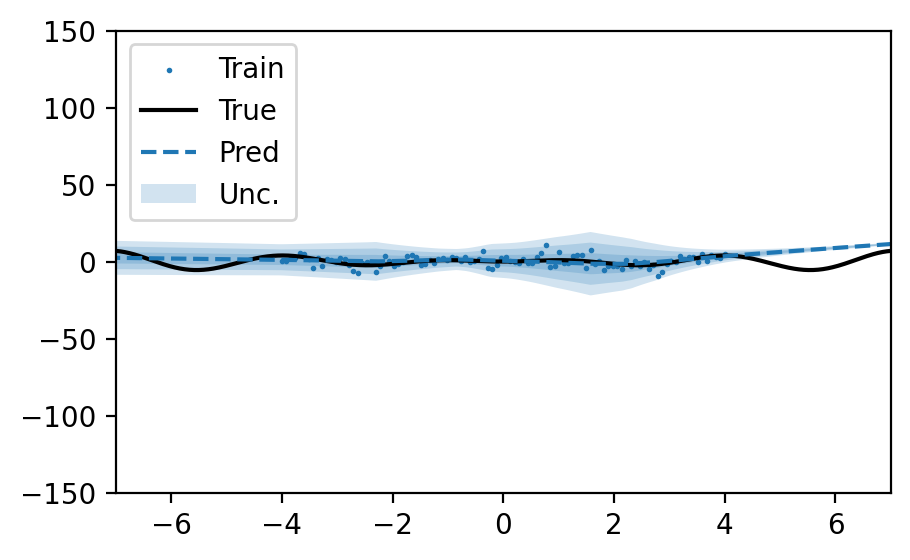

In [6]:
import torch
from torch import nn
import matplotlib.pyplot as plt

from edl_pytorch import NormalInvGamma, evidential_regression


def generate_data(func, x_min_train, x_max_train, num_train=1000, num_test=1000, sigma_scale=3):
    # Training data
    x_train = torch.linspace(x_min_train, x_max_train, num_train).unsqueeze(-1)
    sigma = torch.normal(torch.zeros_like(x_train), sigma_scale * torch.ones_like(x_train))
    y_train = func(x_train) + sigma

    # Automatically set the test range
    test_range = abs(x_max_train - x_min_train) * 0.4
    x_min_test = x_min_train - test_range
    x_max_test = x_max_train + test_range

    # Test data
    x_test = torch.linspace(x_min_test, x_max_test, num_test).unsqueeze(-1)
    y_test = func(x_test)
    
    return x_train, y_train, x_test, y_test


# re-create toy y = x ** 3 + eps example from https://arxiv.org/abs/1910.02600
def main():
    torch.manual_seed(0)

    true_func = lambda x: torch.sin(2 * x) * x 

    x_train, y_train, x_test, y_test = generate_data(
        true_func, 
        x_min_train=-4, 
        x_max_train=4,
        num_train=100,
        num_test=1000,
    )

    model = nn.Sequential(
        nn.Linear(1, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        NormalInvGamma(64, 1),
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    for _ in range(500):
        # Full batch: x_train and y_train used as a whole
        pred = model(x_train)
        loss = evidential_regression(pred, y_train, lamb=1e-2)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f'Epoch: {_}, Loss: {loss.item()}')

    with torch.no_grad():
        pred = model(x_test)

    mu, v, alpha, beta = (d.squeeze() for d in pred)
    x_test = x_test.squeeze()
    var = torch.sqrt(beta / (v * (alpha - 1)))

    # plot code modified from
    # https://github.com/aamini/evidential-deep-learning/blob/main/hello_world.py#L48
    plt.figure(figsize=(5, 3), dpi=200)
    plt.scatter(x_train, y_train, s=1.0, c="tab:blue", label="Train")
    plt.plot(x_test, y_test, c="k", label="True")
    plt.plot(x_test, mu, c="tab:blue", ls="--", label="Pred")
    for std in range(4):
        plt.fill_between(
            x_test,
            (mu - std * var),
            (mu + std * var),
            alpha=0.2,
            facecolor="tab:blue",
            label="Unc." if std == 0 else None,
        )
    plt.gca().set_ylim(-150, 150)
    plt.gca().set_xlim(-7, 7)
    plt.legend(loc="upper left")    



if __name__ == "__main__":
    main()

In [39]:
import torch
from torch import nn
import plotly.graph_objects as go
from edl_pytorch import NormalInvGamma, evidential_regression
from edl_pytorch.loss import nig_nll, nig_reg

def generate_data(func, x_min_train, x_max_train, num_train=1000, num_test=1000, sigma_scale=3, test_additional=0.4):
    # Training data
    x_train = torch.linspace(x_min_train, x_max_train, num_train).unsqueeze(-1)
    sigma = torch.normal(torch.zeros_like(x_train), sigma_scale * torch.ones_like(x_train))
    y_train = func(x_train) + sigma

    # Automatically set the test range based on the ratio (test_add)
    test_range = abs(x_max_train - x_min_train) * test_additional
    x_min_test = x_min_train - test_range
    x_max_test = x_max_train + test_range

    # Test data
    x_test = torch.linspace(x_min_test, x_max_test, num_test).unsqueeze(-1)
    y_test = func(x_test)
    
    return x_train, y_train, x_test, y_test

def main():
    torch.manual_seed(0)

    true_func = lambda x: torch.sin(2 * x) * x 

    x_train, y_train, x_test, y_test = generate_data(
        true_func, 
        x_min_train=4, 
        x_max_train=-4,
        num_train=100,
        num_test=1000,
        sigma_scale=1,
        test_additional=0,
    )

    model = nn.Sequential(
        nn.Linear(1, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        NormalInvGamma(64, 1),
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    for _ in range(500):
        # Full batch: x_train and y_train used as a whole
        pred = model(x_train)
        loss = evidential_regression(pred, y_train, lamb=1e-2)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f'Epoch: {_}, Loss: {loss.item()}')

    with torch.no_grad():
        pred = model(x_test)

    mu, v, alpha, beta = (d.squeeze() for d in pred)
    x_test = x_test.squeeze()
    var = torch.sqrt(beta / (v * (alpha - 1)))

    # plot using plotly
    fig = go.Figure()

    # Add train data points
    fig.add_trace(go.Scatter(x=x_train.squeeze().numpy(), y=y_train.squeeze().numpy(), mode='markers', 
                             marker=dict(size=3, color='blue'), name='Train'))

    # Add true function line
    fig.add_trace(go.Scatter(x=x_test.numpy(), y=y_test.numpy(), mode='lines', 
                             line=dict(color='black', width=2), name='True'))

    # Add predicted mean line
    fig.add_trace(go.Scatter(x=x_test.numpy(), y=mu.numpy(), mode='lines', 
                             line=dict(color='blue', dash='dash'), name='Pred'))

    # Add uncertainty (2 std devs only)
    fig.add_trace(go.Scatter(
        x=x_test.numpy(), 
        y=(mu - 2 * var).numpy(), 
        fill=None, mode='lines', line_color='rgba(0,0,255,0.1)',  # Lighter color
        showlegend=True, name='Unc. (2σ)'
    ))
    fig.add_trace(go.Scatter(
        x=x_test.numpy(), 
        y=(mu + 2 * var).numpy(), 
        fill='tonexty', mode='lines', line_color='rgba(0,0,255,0.1)',
        showlegend=False
    ))

    # Update layout with white background
    fig.update_layout(
        title="Evidential Regression",
        xaxis_title="x",
        yaxis_title="y",
        legend=dict(x=0, y=1),
        plot_bgcolor='white',  # White background
        paper_bgcolor='white'  # White background
    )

    fig.show()


if __name__ == "__main__":
    main()


Epoch: 0, Loss: 2.3764941692352295
Epoch: 1, Loss: 2.3618414402008057
Epoch: 2, Loss: 2.3485801219940186
Epoch: 3, Loss: 2.3366141319274902
Epoch: 4, Loss: 2.3258376121520996
Epoch: 5, Loss: 2.316117525100708
Epoch: 6, Loss: 2.307307720184326
Epoch: 7, Loss: 2.2992639541625977
Epoch: 8, Loss: 2.2918589115142822
Epoch: 9, Loss: 2.2849903106689453
Epoch: 10, Loss: 2.278574228286743
Epoch: 11, Loss: 2.2725119590759277
Epoch: 12, Loss: 2.266758680343628
Epoch: 13, Loss: 2.2612736225128174
Epoch: 14, Loss: 2.256038188934326
Epoch: 15, Loss: 2.2510430812835693
Epoch: 16, Loss: 2.2462871074676514
Epoch: 17, Loss: 2.241770029067993
Epoch: 18, Loss: 2.2374937534332275
Epoch: 19, Loss: 2.2334587574005127
Epoch: 20, Loss: 2.229660987854004
Epoch: 21, Loss: 2.2260935306549072
Epoch: 22, Loss: 2.222745418548584
Epoch: 23, Loss: 2.219604253768921
Epoch: 24, Loss: 2.2166595458984375
Epoch: 25, Loss: 2.2138848304748535
Epoch: 26, Loss: 2.2112605571746826
Epoch: 27, Loss: 2.2087690830230713
Epoch: 28, 

In [48]:
import torch
from torch import nn
import plotly.graph_objects as go
from edl_pytorch import NormalInvGamma
from edl_pytorch.loss import nig_nll, nig_reg

def generate_data(func, x_min_train, x_max_train, num_train=1000, num_test=1000, sigma_scale=3, test_additional=0.4):
    # Training data
    x_train = torch.linspace(x_min_train, x_max_train, num_train).unsqueeze(-1)
    sigma = torch.normal(torch.zeros_like(x_train), sigma_scale * torch.ones_like(x_train))
    y_train = func(x_train) + sigma

    # Automatically set the test range based on the ratio (test_add)
    test_range = abs(x_max_train - x_min_train) * test_additional
    x_min_test = x_min_train - test_range
    x_max_test = x_max_train + test_range

    # Test data
    x_test = torch.linspace(x_min_test, x_max_test, num_test).unsqueeze(-1)
    y_test = func(x_test)
    
    return x_train, y_train, x_test, y_test


class EvidentialMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_units=[64, 64, 64],
        activations=["tanh", "tanh", "tanh"],
        nig_coeff=1e-2,
        epoch_num=500,
        lr=5e-4
    ):
        super(EvidentialMLP, self).__init__()
        layers = []
        in_dim = input_dim

        # Build layers based on the given hidden_units and activations
        for hidden_dim, activation in zip(hidden_units, activations):
            layers.append(nn.Linear(in_dim, hidden_dim))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "tanh":
                layers.append(nn.Tanh())
            elif activation == "sigmoid":
                layers.append(nn.Sigmoid())
            in_dim = hidden_dim

        layers.append(NormalInvGamma(hidden_units[-1], output_dim))
        self.model = nn.Sequential(*layers)

        # Set coefficients for loss components
        self.nig_coeff = nig_coeff

        # Optimizer parameters
        self.epoch_num = epoch_num
        self.lr = lr

    def forward_dist_params(self, x):
        return self.model(x)

    def forward(self, x):
        with torch.no_grad():
            dist_params = self.forward_dist_params(x)
            mu, v, alpha, beta = (d.squeeze() for d in dist_params)
            std = torch.sqrt(beta / (v * (alpha - 1)))
        return mu, std
    
    def compute_loss(self, x, y):
        dist_params = self.forward_dist_params(x)
        return nig_nll(*dist_params, y) + self.nig_coeff * nig_reg(*dist_params, y)
    
    def fit(self, x_train, y_train):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
    
        for epoch in range(self.epoch_num):
            # Full batch: x_train and y_train used as a whole
            loss = self.compute_loss(x_train, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == self.epoch_num - 1:
                print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 2.3764941692352295
Epoch: 10, Loss: 2.278574228286743
Epoch: 20, Loss: 2.229660987854004
Epoch: 30, Loss: 2.2019295692443848
Epoch: 40, Loss: 2.180161952972412
Epoch: 50, Loss: 2.1526834964752197
Epoch: 60, Loss: 2.1252076625823975
Epoch: 70, Loss: 2.103121519088745
Epoch: 80, Loss: 2.0915262699127197
Epoch: 90, Loss: 2.083468198776245
Epoch: 100, Loss: 2.0756373405456543
Epoch: 110, Loss: 2.0683083534240723
Epoch: 120, Loss: 2.0607805252075195
Epoch: 130, Loss: 2.0527029037475586
Epoch: 140, Loss: 2.0436949729919434
Epoch: 150, Loss: 2.03328013420105
Epoch: 160, Loss: 2.020752429962158
Epoch: 170, Loss: 2.0054023265838623
Epoch: 180, Loss: 1.9862496852874756
Epoch: 190, Loss: 1.9621583223342896
Epoch: 200, Loss: 1.9316169023513794
Epoch: 210, Loss: 1.8924168348312378
Epoch: 220, Loss: 1.8417526483535767
Epoch: 230, Loss: 1.7806490659713745
Epoch: 240, Loss: 1.705407738685608
Epoch: 250, Loss: 1.6246013641357422
Epoch: 260, Loss: 1.5461130142211914
Epoch: 270, Loss: 1.4

In [61]:
import torch
from torch import nn
import plotly.graph_objects as go
from edl_pytorch import NormalInvGamma
from edl_pytorch.loss import nig_nll, nig_reg


torch.manual_seed(0)

# Define the true function
true_func = lambda x: torch.sin(2 * x) * x 

def generate_data(func, x_min_train, x_max_train, num_train=1000, num_test=1000, sigma_scale=3, test_additional=0.4):
    # Training data
    x_train = torch.linspace(x_min_train, x_max_train, num_train).unsqueeze(-1)
    sigma = torch.normal(torch.zeros_like(x_train), sigma_scale * torch.ones_like(x_train))
    y_train = func(x_train) + sigma

    # Automatically set the test range based on the ratio (test_add)
    test_range = abs(x_max_train - x_min_train) * test_additional
    x_min_test = x_min_train - test_range
    x_max_test = x_max_train + test_range

    # Test data
    x_test = torch.linspace(x_min_test, x_max_test, num_test).unsqueeze(-1)
    y_test = func(x_test)
    
    return x_train, y_train, x_test, y_test


# Generate train and test data
x_train, y_train, x_test, y_test = generate_data(
    true_func, 
    x_min_train=4, 
    x_max_train=-4,
    num_train=100,
    num_test=1000,
    sigma_scale=1,
    test_additional=0,
)


class EvidentialMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_units=[64, 64, 64],
        activations=["tanh", "tanh", "tanh"],
        nig_coeff=1e-2,
        epoch_num=500,
        lr=5e-4
    ):
        super(EvidentialMLP, self).__init__()
        layers = []
        in_dim = input_dim

        # Build layers based on the given hidden_units and activations
        for hidden_dim, activation in zip(hidden_units, activations):
            layers.append(nn.Linear(in_dim, hidden_dim))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "tanh":
                layers.append(nn.Tanh())
            elif activation == "sigmoid":
                layers.append(nn.Sigmoid())
            in_dim = hidden_dim

        layers.append(NormalInvGamma(hidden_units[-1], output_dim))
        self.model = nn.Sequential(*layers)

        # Set coefficients for loss components
        self.nig_coeff = nig_coeff

        # Optimizer parameters
        self.epoch_num = epoch_num
        self.lr = lr

    def forward_dist_params(self, x):
        return self.model(x)

    def forward(self, x):
        with torch.no_grad():
            dist_params = self.forward_dist_params(x)
            mu, v, alpha, beta = (d.squeeze() for d in dist_params)
            std = torch.sqrt(beta / (v * (alpha - 1)))
        return mu, std
    
    def compute_loss(self, x, y):
        dist_params = self.forward_dist_params(x)
        return nig_nll(*dist_params, y) + self.nig_coeff * nig_reg(*dist_params, y)
    
    def fit(self, x_train, y_train):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
    
        for epoch in range(self.epoch_num):
            # Full batch: x_train and y_train used as a whole
            loss = self.compute_loss(x_train, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == self.epoch_num - 1:
                print(f'Epoch: {epoch}, Loss: {loss.item()}')


# Create Evidential MLP model
model = EvidentialMLP(
    input_dim=1, 
    output_dim=1,
    hidden_units=[64, 64, 64],
    activations=["tanh", "tanh", "tanh"],
    nig_coeff=1e-2,
    epoch_num=500,
    lr=5e-4
)

# Train the model
model.fit(x_train, y_train)

# Make predictions on test data
mean, std = model(x_test)

# Prepare data for visualization
mean, std = mean.squeeze().numpy(), std.squeeze().numpy()
x_test, y_test = x_test.squeeze().numpy(), y_test.squeeze().numpy()

# Plot using Plotly
fig = go.Figure()

# Add train data points
fig.add_trace(go.Scatter(x=x_train.squeeze().numpy(), y=y_train.squeeze().numpy(), mode='markers', 
                         marker=dict(size=3, color='blue'), name='Train'))

# Add true function line
fig.add_trace(go.Scatter(x=x_test, y=y_test, mode='lines', 
                         line=dict(color='black', width=2), name='True'))

# Add predicted mean line
fig.add_trace(go.Scatter(x=x_test, y=mean, mode='lines', 
                         line=dict(color='blue', dash='dash'), name='Pred'))

# Add uncertainty (2 std devs only)
fig.add_trace(go.Scatter(
    x=x_test, 
    y=(mean - 2 * std), 
    fill=None, mode='lines', line_color='rgba(0,0,255,0.1)',  # Lighter color
    showlegend=True, name='Unc. (2σ)'
))
fig.add_trace(go.Scatter(
    x=x_test, 
    y=(mean + 2 * std), 
    fill='tonexty', mode='lines', line_color='rgba(0,0,255,0.1)',
    showlegend=False
))

# Update layout with white background
fig.update_layout(
    title="Evidential Regression",
    xaxis_title="x",
    yaxis_title="y",
    legend=dict(x=0, y=1),
    plot_bgcolor='white',  # White background
    paper_bgcolor='white'  # White background
)

fig.show()

Epoch: 0, Loss: 2.3764941692352295
Epoch: 10, Loss: 2.278574228286743
Epoch: 20, Loss: 2.229660987854004
Epoch: 30, Loss: 2.2019295692443848
Epoch: 40, Loss: 2.180161952972412
Epoch: 50, Loss: 2.1526834964752197
Epoch: 60, Loss: 2.1252076625823975
Epoch: 70, Loss: 2.103121519088745
Epoch: 80, Loss: 2.0915262699127197
Epoch: 90, Loss: 2.083468198776245
Epoch: 100, Loss: 2.0756373405456543
Epoch: 110, Loss: 2.0683083534240723
Epoch: 120, Loss: 2.0607805252075195
Epoch: 130, Loss: 2.0527029037475586
Epoch: 140, Loss: 2.0436949729919434
Epoch: 150, Loss: 2.03328013420105
Epoch: 160, Loss: 2.020752429962158
Epoch: 170, Loss: 2.0054023265838623
Epoch: 180, Loss: 1.9862496852874756
Epoch: 190, Loss: 1.9621583223342896
Epoch: 200, Loss: 1.9316169023513794
Epoch: 210, Loss: 1.8924168348312378
Epoch: 220, Loss: 1.8417526483535767
Epoch: 230, Loss: 1.7806490659713745
Epoch: 240, Loss: 1.705407738685608
Epoch: 250, Loss: 1.6246013641357422
Epoch: 260, Loss: 1.5461130142211914
Epoch: 270, Loss: 1.4

In [59]:
# Prepare data for visualization
mean, std = mean.squeeze().numpy(), std.squeeze().numpy()
x_test, y_test = x_test.squeeze().numpy(), y_test.squeeze().numpy()

In [56]:
mean, std = model(x_test)

In [57]:
std

tensor([0.7518, 0.7536, 0.7553, 0.7571, 0.7588, 0.7606, 0.7624, 0.7642, 0.7660,
        0.7678, 0.7697, 0.7715, 0.7734, 0.7753, 0.7772, 0.7791, 0.7810, 0.7829,
        0.7849, 0.7868, 0.7888, 0.7908, 0.7928, 0.7948, 0.7968, 0.7988, 0.8009,
        0.8029, 0.8050, 0.8071, 0.8092, 0.8113, 0.8134, 0.8156, 0.8177, 0.8199,
        0.8220, 0.8242, 0.8264, 0.8286, 0.8308, 0.8331, 0.8353, 0.8376, 0.8398,
        0.8421, 0.8444, 0.8467, 0.8490, 0.8513, 0.8536, 0.8560, 0.8583, 0.8607,
        0.8630, 0.8654, 0.8678, 0.8702, 0.8726, 0.8750, 0.8774, 0.8798, 0.8823,
        0.8847, 0.8871, 0.8896, 0.8921, 0.8945, 0.8970, 0.8995, 0.9020, 0.9044,
        0.9069, 0.9094, 0.9119, 0.9144, 0.9170, 0.9195, 0.9220, 0.9245, 0.9270,
        0.9295, 0.9321, 0.9346, 0.9371, 0.9396, 0.9422, 0.9447, 0.9472, 0.9497,
        0.9523, 0.9548, 0.9573, 0.9598, 0.9623, 0.9648, 0.9674, 0.9699, 0.9724,
        0.9748, 0.9773, 0.9798, 0.9823, 0.9848, 0.9872, 0.9897, 0.9921, 0.9946,
        0.9970, 0.9994, 1.0019, 1.0043, 

In [60]:
# Plot using Plotly
fig = go.Figure()

# Add train data points
fig.add_trace(go.Scatter(x=x_train.squeeze().numpy(), y=y_train.squeeze().numpy(), mode='markers', 
                         marker=dict(size=3, color='blue'), name='Train'))

# Add true function line
fig.add_trace(go.Scatter(x=x_test, y=y_test, mode='lines', 
                         line=dict(color='black', width=2), name='True'))

# Add predicted mean line
fig.add_trace(go.Scatter(x=x_test, y=mean, mode='lines', 
                         line=dict(color='blue', dash='dash'), name='Pred'))

# Add uncertainty (2 std devs only)
fig.add_trace(go.Scatter(
    x=x_test, 
    y=(mean - 2 * std), 
    fill=None, mode='lines', line_color='rgba(0,0,255,0.1)',  # Lighter color
    showlegend=True, name='Unc. (2σ)'
))
fig.add_trace(go.Scatter(
    x=x_test, 
    y=(mean + 2 * std), 
    fill='tonexty', mode='lines', line_color='rgba(0,0,255,0.1)',
    showlegend=False
))

# Update layout with white background
fig.update_layout(
    title="Evidential Regression",
    xaxis_title="x",
    yaxis_title="y",
    legend=dict(x=0, y=1),
    plot_bgcolor='white',  # White background
    paper_bgcolor='white'  # White background
)

fig.show()
